<a href="https://colab.research.google.com/github/ganraj07/SYNTECXHUB-ML-PROJECTS/blob/main/Project1_(Customer_Segmentation)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# ==========================================================

# ==========================
# STEP 1: Import Libraries
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Mall_Customers.xlsx to Mall_Customers (1).xlsx


In [ ]:
# ==========================
# STEP 2: Load Dataset
# ==========================

df = pd.read_excel("/content/Mall_Customers.xlsx")

print("First 5 Rows:")
print(df.head())

print("\nShape:", df.shape)


First 5 Rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape: (200, 5)


In [ ]:
# ==========================
# STEP 3: Data Cleaning
# ==========================

print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)



Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


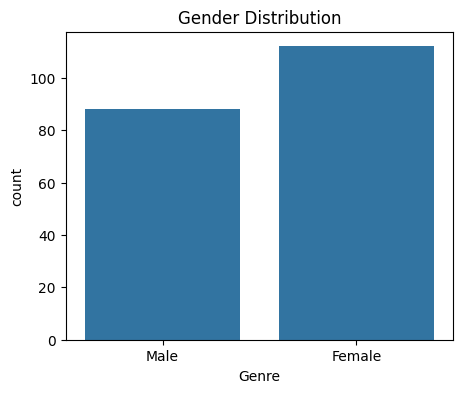

In [ ]:
# ==========================
# STEP 4: Exploratory Data Analysis
# ==========================

# Gender Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Genre", data=df)
plt.title("Gender Distribution")
plt.show()

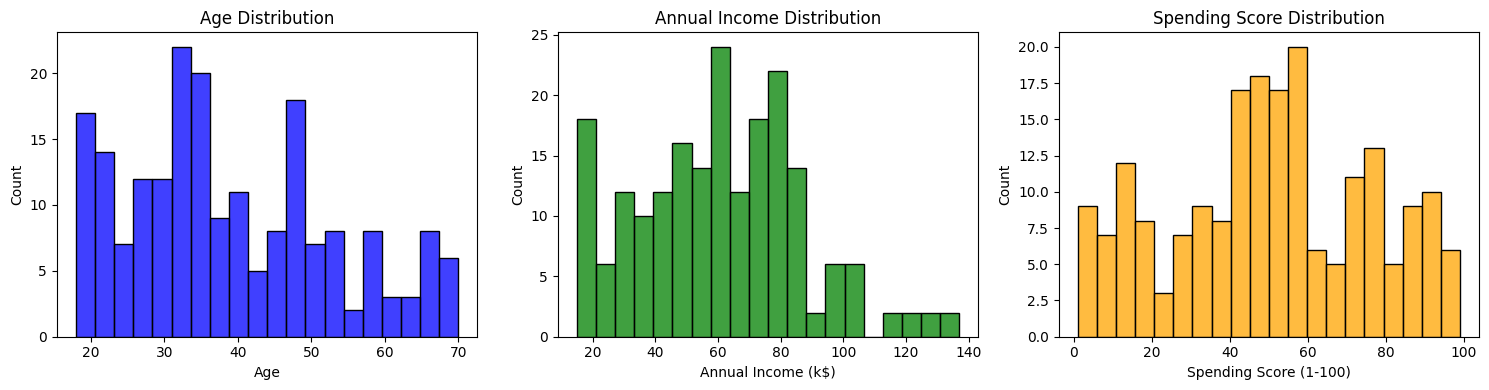

In [ ]:
# Histograms
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(df["Age"], bins=20, color="blue")
plt.title("Age Distribution")

plt.subplot(1,3,2)
sns.histplot(df["Annual Income (k$)"], bins=20, color="green")
plt.title("Annual Income Distribution")

plt.subplot(1,3,3)
sns.histplot(df["Spending Score (1-100)"], bins=20, color="orange")
plt.title("Spending Score Distribution")

plt.tight_layout()
plt.show()

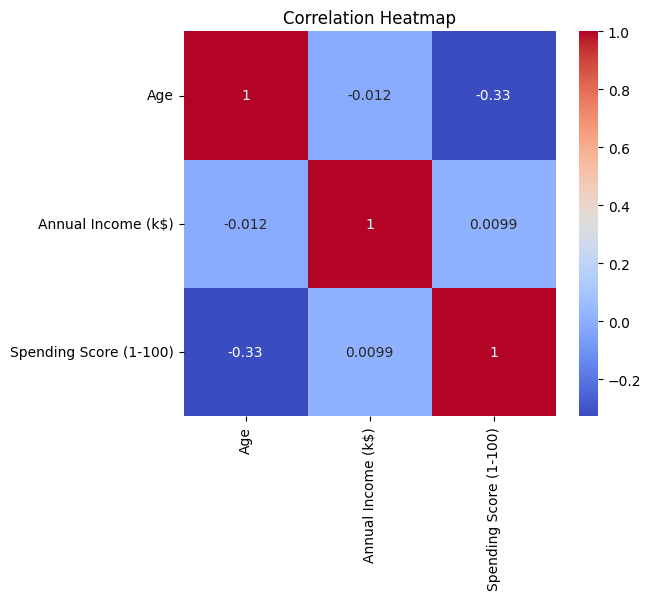

In [ ]:
# Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    df[["Age","Annual Income (k$)","Spending Score (1-100)"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ==========================
# STEP 5: Feature Selection
# ==========================

X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# ==========================
# STEP 6: Feature Scaling
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

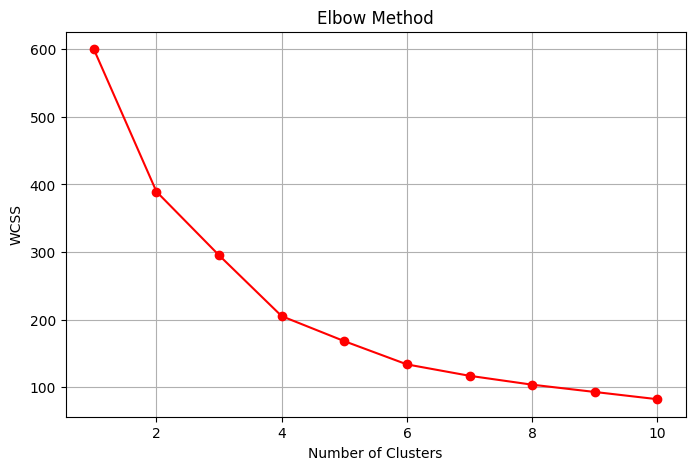

In [ ]:
# ==========================
# STEP 7: Elbow Method
# ==========================

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o", color="red")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [ ]:
# ==========================
# STEP 8: K-Means Clustering
# ==========================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nClusters Added Successfully!")



Clusters Added Successfully!


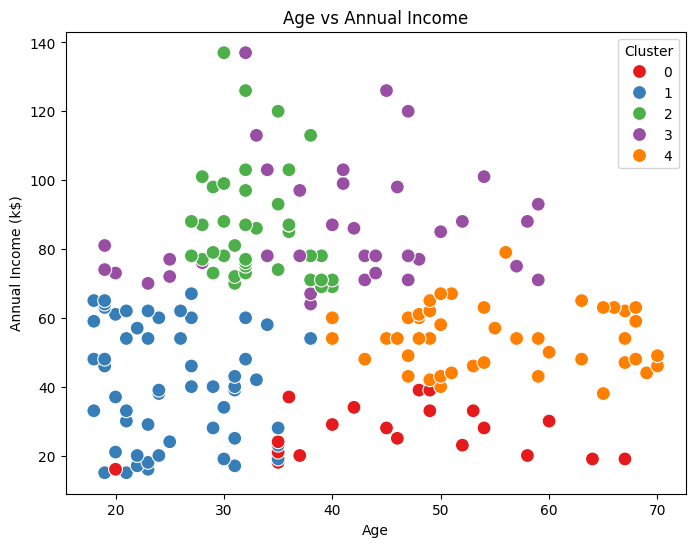

In [ ]:
# ==========================
# STEP 9: Scatter Plot
# Age vs Income
# ==========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Annual Income (k$)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Age vs Annual Income")

plt.show()

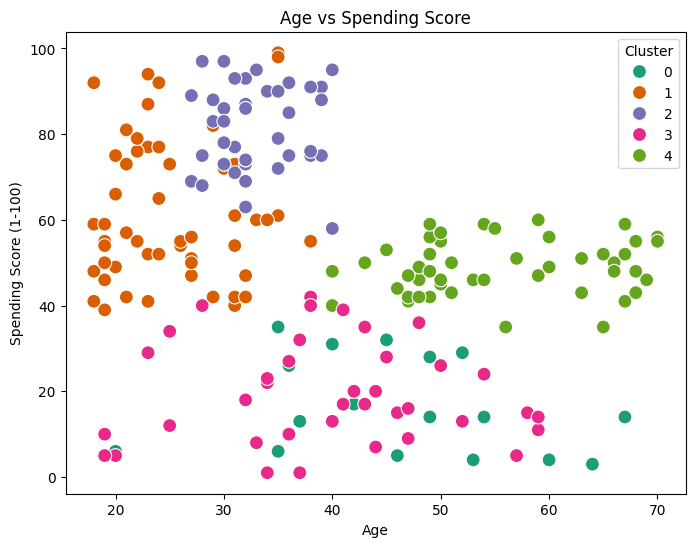

In [ ]:
# ==========================
# Age vs Spending Score
# ==========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Dark2",
    s=100
)

plt.title("Age vs Spending Score")

plt.show()


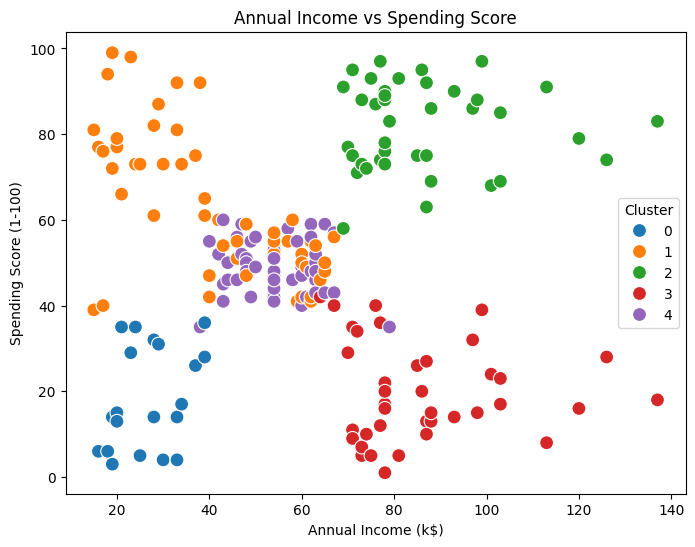

In [ ]:
# ==========================
# Income vs Spending Score
# ==========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("Annual Income vs Spending Score")

plt.show()

In [ ]:
# ==========================
# STEP 10: Cluster Profile
# ==========================

profile = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print("\nCluster Profile")
print(profile)

# ==========================
# STEP 11: Cluster Centers
# ==========================

centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(
    centers,
    columns=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

print("\nCluster Centers")
print(centers.round(2))



Cluster Profile
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064

Cluster Centers
     Age  Annual Income (k$)  Spending Score (1-100)
0  46.25               26.75                   18.35
1  25.19               41.09                   62.24
2  32.88               86.10                   81.53
3  39.87               86.10                   19.36
4  55.64               54.38                   48.85


In [ ]:
# ==========================
# STEP 12: Marketing Report
# ==========================

print("\n")
print("="*60)
print("CUSTOMER SEGMENT REPORT")
print("="*60)

for cluster in sorted(df.Cluster.unique()):

    segment = df[df.Cluster==cluster]

    age = segment["Age"].mean()
    income = segment["Annual Income (k$)"].mean()
    spending = segment["Spending Score (1-100)"].mean()

    print("\nCluster:", cluster)
    print("Customers:", len(segment))
    print("Average Age:", round(age,1))
    print("Average Income:", round(income,1))
    print("Average Spending Score:", round(spending,1))

    if income > 70 and spending > 70:
        print("Marketing Action: Premium customers - Offer VIP memberships and exclusive products.")

    elif income > 70 and spending < 40:
        print("Marketing Action: High-income customers - Encourage purchases with personalized offers.")

    elif income < 50 and spending > 60:
        print("Marketing Action: Frequent shoppers - Offer loyalty rewards and cashback.")

    else:
        print("Marketing Action: Regular promotional campaigns and seasonal discounts.")




CUSTOMER SEGMENT REPORT

Cluster: 0
Customers: 20
Average Age: 46.2
Average Income: 26.8
Average Spending Score: 18.4
Marketing Action: Regular promotional campaigns and seasonal discounts.

Cluster: 1
Customers: 54
Average Age: 25.2
Average Income: 41.1
Average Spending Score: 62.2
Marketing Action: Frequent shoppers - Offer loyalty rewards and cashback.

Cluster: 2
Customers: 40
Average Age: 32.9
Average Income: 86.1
Average Spending Score: 81.5
Marketing Action: Premium customers - Offer VIP memberships and exclusive products.

Cluster: 3
Customers: 39
Average Age: 39.9
Average Income: 86.1
Average Spending Score: 19.4
Marketing Action: High-income customers - Encourage purchases with personalized offers.

Cluster: 4
Customers: 47
Average Age: 55.6
Average Income: 54.4
Average Spending Score: 48.9
Marketing Action: Regular promotional campaigns and seasonal discounts.


In [ ]:
# ==========================
# STEP 14: Predict New Customer
# ==========================

new_customer = [[30,60,80]]

new_scaled = scaler.transform(new_customer)

prediction = kmeans.predict(new_scaled)

print("\nPredicted Cluster:", prediction[0])

print("\nProject Completed Successfully!")


Predicted Cluster: 2

Project Completed Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
